In [3]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [7]:
df.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [11]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [13]:
performance = df.dropna(axis=0)

In [15]:
performance.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [17]:
performance.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000,6378.000000
mean,19.977109,80.020853,7.034964,75.066165,1.495296,2.972719,67.252117
std,5.985460,11.550723,1.468033,14.400389,1.233984,1.028926,3.914217
min,1.000000,60.000000,4.000000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.000000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.000000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.000000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.000000,100.000000,8.000000,6.000000,101.000000


In [19]:
#Selecting only numerical columns for correlation heatmap
numeric = performance.select_dtypes(include=['int64', 'float64'])

In [21]:
#Creating a correlation matrix
correlation = numeric.corr()

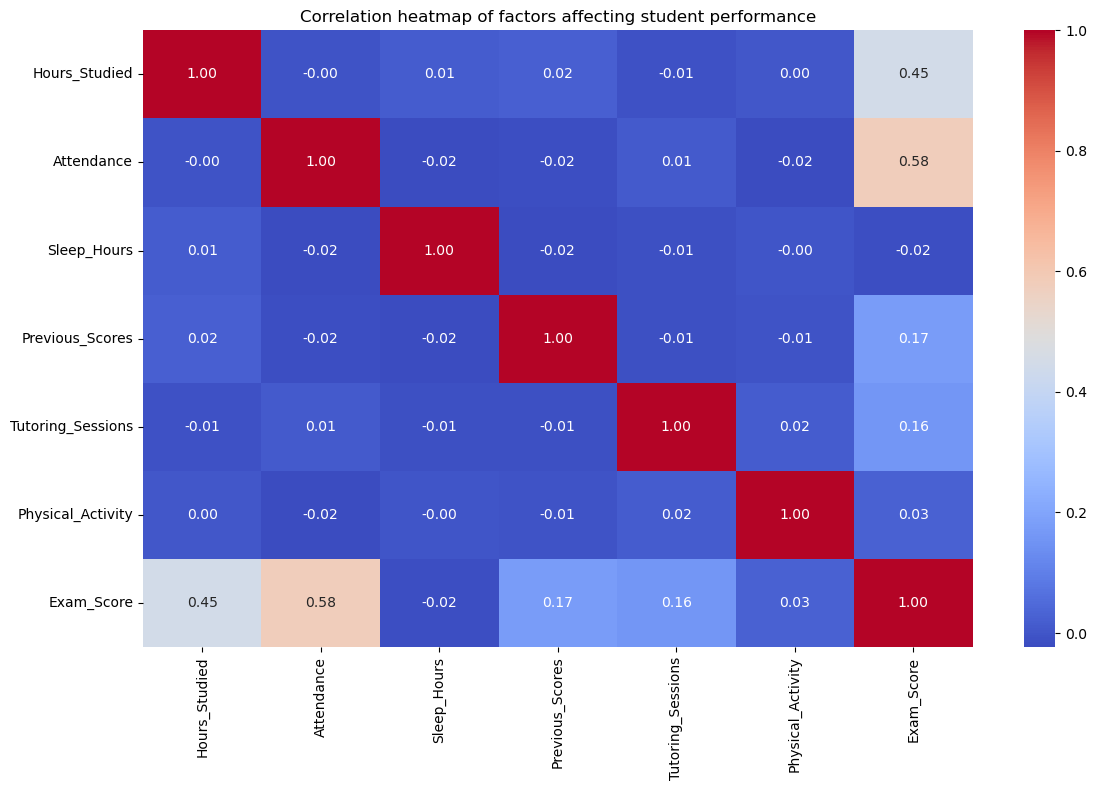

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(correlation,
            annot=True,         #show numbers
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation heatmap of factors affecting student performance")
plt.tight_layout()
plt.show()

In [24]:
from sklearn.model_selection import train_test_split

X = performance.drop("Exam_Score", axis=1) #All input variables except for the target variable
y = performance["Exam_Score"]

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,                 #20% for testing
    random_state = 42                #ensures reproducibility
    )

In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5102, 27)
(1276, 27)
(5102,)
(1276,)


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

#Training the model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)  #Predict

#Evaluate
print("R²:", r2_score(y_test, y_pred))

R²: 0.7314386522127074


In [27]:
print(X_train.shape)
print(X_test.shape)

(5102, 27)
(1276, 27)


In [28]:
print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

Train R²: 0.7187813703799608
Test R²: 0.7314386522127074


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error #Checking other error metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 0.4872872342743075
MSE: 4.173262062207913
RMSE: 2.0428563488918923


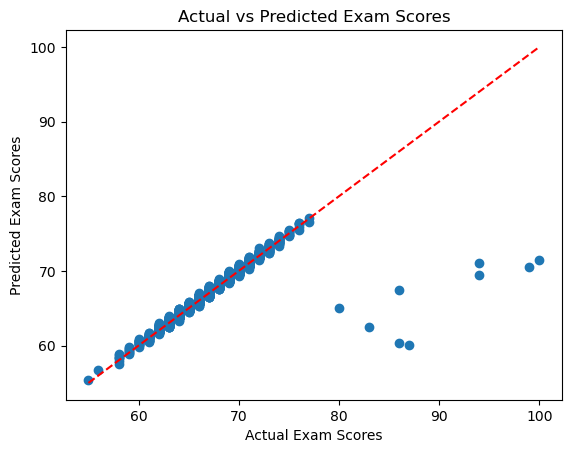

In [30]:
#Visualization of patterns and errors for predictions
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Exam Scores")
plt.ylabel("Predicted Exam Scores")
plt.title("Actual vs Predicted Exam Scores")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.show()

In [31]:
#Interpreting Model Coefficients to see which factors have the biggest effect on exam scores
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coefficients)

                                  Feature  Coefficient
20                Peer_Influence_Positive     1.014880
13                    Internet_Access_Yes     0.900608
25                Distance_from_Home_Near     0.841829
10         Extracurricular_Activities_Yes     0.566723
19                 Peer_Influence_Neutral     0.561867
23  Parental_Education_Level_Postgraduate     0.521576
4                       Tutoring_Sessions     0.482777
24            Distance_from_Home_Moderate     0.304964
0                           Hours_Studied     0.295834
5                       Physical_Activity     0.200224
1                              Attendance     0.198689
18                     School_Type_Public     0.048959
3                         Previous_Scores     0.048514
26                            Gender_Male    -0.010802
2                             Sleep_Hours    -0.012829
22   Parental_Education_Level_High School    -0.476205
12                Motivation_Level_Medium    -0.598881
17        

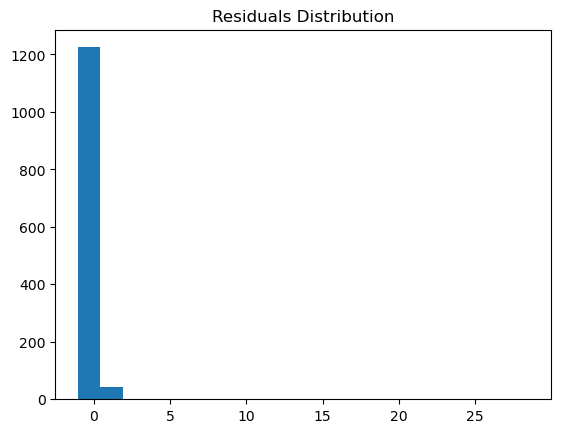

In [32]:
residuals = y_test - y_pred
plt.hist(residuals, bins=20)
plt.title("Residuals Distribution")
plt.show()

In [33]:
new_student = X.iloc[[0]].copy()
new_student.iloc[0,0:8] = [5,7,80,2,1,3,1,2]

prediction = model.predict(new_student)

print("Predicted Exam Score:", prediction)

Predicted Exam Score: [40.44086283]


C:\Users\nozim\AppData\Local\Temp\ipykernel_33296\2497202376.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  new_student.iloc[0,0:8] = [5,7,80,2,1,3,1,2]
C:\Users\nozim\AppData\Local\Temp\ipykernel_33296\2497202376.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  new_student.iloc[0,0:8] = [5,7,80,2,1,3,1,2]


In [34]:
new_student = X.iloc[[0]]
prediction = model.predict(new_student)

print("Predicted Exam Score:", prediction[0])

Predicted Exam Score: 67.04025365446444
